In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.cluster import KMeans #군집화 알고리즘, 라벨 x는 데이터 -> 비슷한 특성끼리 묶는(클러스터링)데 사용 
from sklearn.datasets import make_blobs #K-Means, DBSCAN 등 테스트 시, 임의의 점(데이터 포인트)를 여러 개의 중심을 기준으로 흩뿌려서 만들어 줌.
                                        #가짜 데이터 생성기(데이터셋 생성 함수)

In [4]:
np.random.seed(101) #랜덤 인자 시작하는 수 정하기

In [5]:
centerLocation=[[3,2],[1,-1],[-1,2]]

x,_ = make_blobs(n_samples=1500, centers=centerLocation) #데이터 포인트들을 여러 개의 군집(Blob)으로 생성하는 함수
x.shape

(1500, 2)

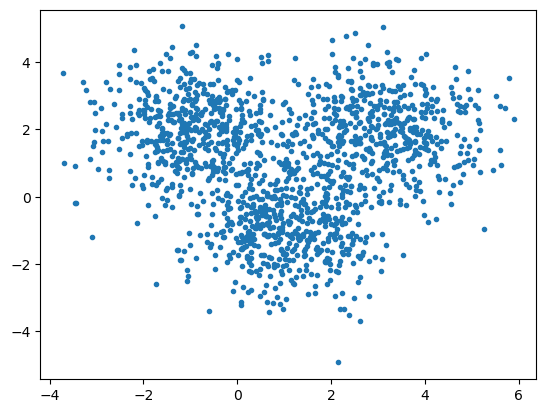

In [9]:
plt.scatter(x[:,0], x[:,1],marker='.') #산점도 그리는 함수

In [11]:
print(x.shape)
print(x[:10])

(1500, 2)
[[-1.21729731  0.34549836]
 [-1.21658421 -1.87049396]
 [ 4.14277516  2.67891613]
 [ 1.2492407   0.54037484]
 [ 4.09955027  0.97450081]
 [ 0.92034431 -0.64397538]
 [ 0.61013832 -0.57942099]
 [ 1.98458314 -2.18392424]
 [-0.24473773  2.72739937]
 [-1.29350714  0.90821259]]


In [13]:
nclusters = 3

In [15]:
k_means=KMeans(n_clusters=nclusters) #K-MEANS 알고리즘으로 n개의 군집으로 분류 -> 모델 생성

In [17]:
k_means.fit(x) #학습

KMeans(n_clusters=3)

In [19]:
k_means?

Type:        KMeans
String form: KMeans(n_clusters=3)
File:        c:\programdata\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py
Docstring:  
K-Means clustering.

Read more in the :ref:`User Guide <k_means>`.

Parameters
----------

n_clusters : int, default=8
    The number of clusters to form as well as the number of
    centroids to generate.

    For an example of how to choose an optimal value for `n_clusters` refer to
    :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.

init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
    Method for initialization:

    * 'k-means++' : selects initial cluster centroids using sampling             based on an empirical probability distribution of the points'             contribution to the overall inertia. This technique speeds up             convergence. The algorithm implemented is "greedy k-means++". It             differs from the vanilla 

In [21]:
k_means.labels_ #각 데이터의 군집 인덱스

array([2, 0, 1, ..., 0, 2, 2])

In [24]:
centers = k_means.cluster_centers_ #군집 중심 좌표
centers

array([[ 1.05328721, -0.96170352],
       [ 3.14738308,  2.02818883],
       [-0.97958037,  2.04290344]])

In [38]:
from matplotlib.colors import ListedColormap #(사용자 정의 팔레트 생성)
#Matplotlib (색상 체계)
#1. 연속형 : LinearSegmentedColormap(연속된 값)
#2. 이산형 : ListedColormap(카테고리형 값)
colors_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF']) #
colors_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])

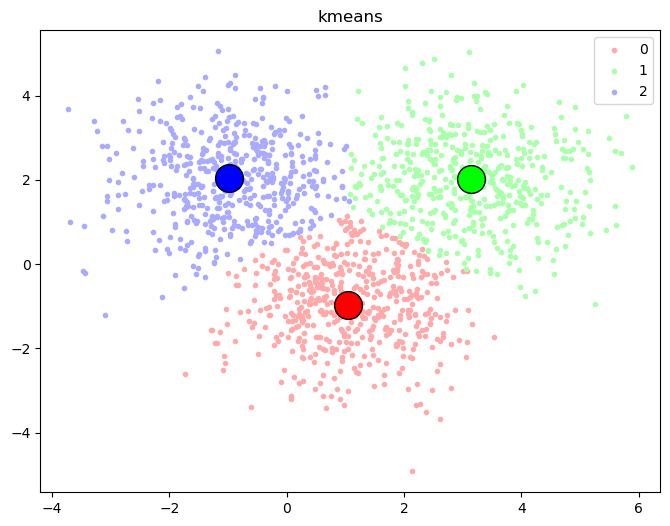

In [64]:
plt.figure(figsize=(8,6)) #canvas 도화지 만드는 함수

for i in range(nclusters):
    members = k_means.labels_ == i
    plt.scatter(x[members,0], x[members,1], marker='.', color=colors_light(i), label=i) #산점도 그리는 함수
    plt.plot(centers[i,0], centers[i,1], 'o', markersize=20, color=colors_bold(i), markeredgecolor='k') #선으로 연결->시각화
plt.title("kmeans")
plt.legend()